### First Step : Clean raw data 

The dataset has been downloaded from the website ... . Some columns are completely useless (bookmakers infos) and some rows are full of missing values. The first step is to clean the dataset.

In [1]:
import pandas as pd
from Data.data_cleaning import Datacleaner

In [ ]:
cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2607,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Dataset_clean.csv")

In [2]:
df = pd.read_csv("./Data/Dataset_clean.csv")

print(df)


     Div        Date   Time    HomeTeam      AwayTeam  FTHG  FTAG FTR  HTHG  \
0     F1    07/08/10  00:00     Auxerre       Lorient   2.0   2.0   D   1.0   
1     F1    07/08/10  00:00        Lens         Nancy   1.0   2.0   A   0.0   
2     F1    07/08/10  00:00        Lyon        Monaco   0.0   0.0   D   0.0   
3     F1    07/08/10  00:00   Marseille          Caen   1.0   2.0   A   0.0   
4     F1    07/08/10  00:00        Nice  Valenciennes   0.0   0.0   D   0.0   
...   ..         ...    ...         ...           ...   ...   ...  ..   ...   
5589  F1  14/12/2025  14:00        Lyon      Le Havre   1.0   0.0   H   0.0   
5590  F1  14/12/2025  16:15     Auxerre         Lille   3.0   4.0   A   0.0   
5591  F1  14/12/2025  16:15        Lens          Nice   2.0   0.0   H   1.0   
5592  F1  14/12/2025  16:15  Strasbourg       Lorient   0.0   0.0   D   0.0   
5593  F1  14/12/2025  19:45   Marseille        Monaco   1.0   0.0   H   0.0   

      HTAG  ...  AST    HC   AC    HF    AF   HY   

### Second step : Classical Bradley-Terry

In [3]:
from Data.data_processing import DataProcesser

In [4]:
processer = DataProcesser("./Data/Dataset_clean.csv")

'''processer = processer.filter_year("10-11")'''

data = processer.get_data()

teams = data['Teams']
W_matrix = data['Victory Matrix']
D_matrix = data['Draw Matrix']


In [6]:
from BradleyTerry_classical.BT_classical import BradleyTerry

In [7]:
bt_model = BradleyTerry(lambda_draw=-1, learning_rate=0.01, n_iterations=1000)
bt_model.fit(W=W_matrix, D=D_matrix, teams=teams)

strength = bt_model.predict_strength()

Tolerance threshold attained after 439 iterations


In [ ]:
result = {team: float(value) for team,value in zip(bt_model.teams,strength)}
result

In [9]:
from Test.test_BT_classical import BT_classical_TEST

In [ ]:
test = BT_classical_TEST(bt_model)

test.run_all()

Tolerance threshold attained after 377 iterations
Tolerance threshold attained after 379 iterations
Tolerance threshold attained after 381 iterations
Tolerance threshold attained after 384 iterations
Tolerance threshold attained after 387 iterations
Tolerance threshold attained after 390 iterations
Tolerance threshold attained after 395 iterations
Tolerance threshold attained after 400 iterations
Tolerance threshold attained after 406 iterations
Tolerance threshold attained after 413 iterations
Tolerance threshold attained after 422 iterations
Tolerance threshold attained after 432 iterations
Tolerance threshold attained after 444 iterations
Tolerance threshold attained after 458 iterations
Tolerance threshold attained after 475 iterations
Tolerance threshold attained after 495 iterations
Tolerance threshold attained after 519 iterations
Tolerance threshold attained after 547 iterations
Tolerance threshold attained after 580 iterations
Tolerance threshold attained after 619 iterations


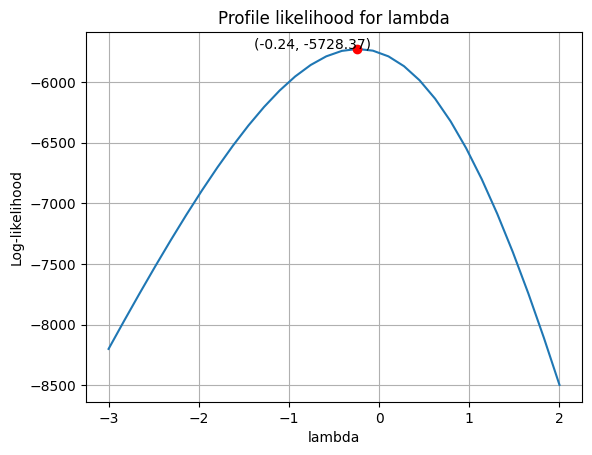

In [15]:
import numpy as np
lambda_grid= np.linspace(-3,2,30)

logliks = []

for lambda_draw in lambda_grid:
    bt_model = BradleyTerry(lambda_draw=lambda_draw, learning_rate=0.01, n_iterations=1000)
    bt_model.fit(W=W_matrix, D=D_matrix, teams=teams)
    theta_hat = bt_model.predict_strength()
    loglik = bt_model.loglikelihood(theta=theta_hat)
    logliks.append(loglik)

lambda_opt = lambda_grid[np.argmax(logliks)]

import matplotlib.pyplot as plt

plt.plot(lambda_grid, logliks)
plt.plot(lambda_opt, max(logliks), 'ro', label='Optimal lambda')
plt.annotate(f'({lambda_opt:.2f}, {max(logliks):.2f})', xy=(lambda_opt, max(logliks)), xytext=(lambda_opt - 0.5, max(logliks) + 0.1), ha='center')
plt.xlabel("lambda")
plt.ylabel("Log-likelihood")
plt.title("Profile likelihood for lambda")
plt.grid()
plt.show()